In [2]:
#libraries 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
np.random.seed(0)


In [3]:
#dataset for training the algorithm
#from extended modified national institute of standards and technology

data = pd.read_csv("./train.csv")
m, n = data.shape
print(data.head(5))
data = np.array(data)
np.random.shuffle(data) #shuffle the data so that they are not in order

#data used for validation and testing.
data_dev = data[0:1000].T#change the shape of the array by transpose.
Y_dev = data_dev[0] #set Y as the labels
X_dev = data_dev[1:n] #set X as the pixels
X_dev = X_dev/225 # normalize the range of the pixes from 0 to 1

#same this as above but this is for training the neural network
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train/225





   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [4]:
#creating the weights for each neurons.
def init_params():
    input = np.random.randn(784, 784) * 0.1
    inputb = np.zeros((784,1))
    mid1 = np.random.randn(784,784) * 0.1
    mid1b = np.zeros((784,1))
    output = np.random.randn(10, 784) * 0.1
    outputb = np.zeros((10,1))
    return input, inputb, mid1, mid1b, output, outputb


input, inputb, mid1, mid1b, output, outputb = init_params()
print(input)
print(inputb)


[[-0.12198828 -0.00668723  0.04917222 ...  0.02763188  0.11737835
  -0.08113679]
 [ 0.04808428 -0.08791852  0.02634968 ... -0.05400172  0.08523033
   0.00277114]
 [ 0.21040093 -0.14332144  0.08153598 ... -0.08038818  0.01948238
   0.01175146]
 ...
 [-0.12585642 -0.10031931  0.05200768 ... -0.0333576   0.05262404
  -0.0259873 ]
 [ 0.07541308  0.32208443 -0.03701568 ... -0.17504428  0.03656465
  -0.07964463]
 [-0.17283386  0.0828121  -0.17695628 ... -0.1522843  -0.03010113
  -0.05432343]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.

In [5]:
# RELU activation function.
def ReLU(Z):
    return np.maximum(Z, 0)

#The softmax function.
def softmax(Z):
   A = np.exp(Z) / sum(np.exp(Z))
   return A



In [6]:
def ReLU_deriv(Z):
    return Z > 0 #used to make the backpropagation efficient.

In [7]:
#One hot encode function 
#This turns the array of the desired values into 1 at the index of the wanted values and zero at the others.

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y


In [8]:
def forward_prop(input, inputb, mid1, mid1b, output, outputb, X):
    Z1 = input.dot(X) + inputb
    A1 = ReLU(Z1)
    Z2 = mid1.dot(A1) + mid1b
    A2 = ReLU(Z2)
    Z3 = output.dot(A2) + outputb
    A3 = softmax(Z3)
    return Z1,A1,Z2,A2,Z3,A3

In [9]:
#uses the change rule

def backward_prop(Z1, A1, Z2, A2, Z3, A3, W1, W2, W3, X, Y):
    one_hot_Y = one_hot(Y)

    dZ3 = A3 - one_hot_Y                     
    dW3 = 1 / m * dZ3.dot(A2.T) # 1/m is used for averaging.     
    db3 = 1 / m * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = W3.T.dot(dZ3)
    dZ2 = dA2 * ReLU_deriv(Z2)              
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = W2.T.dot(dZ2)
    dZ1 = dA1 * ReLU_deriv(Z1)              
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

In [10]:
#updating parameters
#uses the gradient descent function to update the formula, alpha  = learnig rate.
def update_params(input, inputb, mid1, midb, output, outputb, dW1, db1, dW2, db2, dw3, db3, alpha):
    input = input - alpha * dW1
    inputb = inputb - alpha * db1    
    mid1 = mid1 - alpha * dW2  
    midb = midb - alpha * db2
    output = output - alpha * dw3
    outputb = outputb - alpha * db3
    return input, inputb, mid1, midb, output, outputb

In [11]:
#functions for checking which numebers

def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

In [12]:
#training of the function

def gradient_descent(X, Y, alpha, iterations):
    input, inputb, mid1, midb, output, outputb = init_params()
    for i in range(iterations):
        Z1,A1,Z2,A2,Z3,A3 = forward_prop(input, inputb, mid1, midb, output, outputb, X)
        dW1, db1, dW2, db2, dW3, db3 = backward_prop(Z1, A1, Z2, A2, Z3, A3, input, mid1, output, X, Y)
        input, inputb, mid1, midb, output, outputb = update_params(input, inputb, mid1, midb, output, outputb, dW1, db1, dW2, db2, dW3, db3, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A3)
            print(get_accuracy(predictions, Y))
    return input, inputb, mid1, midb, output, outputb

In [17]:
input, inputb, mid1, midb, output, outputb = gradient_descent(X_train, Y_train, 0.1, 500)

Iteration:  0
[3 4 9 ... 3 9 3] [4 9 8 ... 9 0 9]
0.11075609756097561
Iteration:  10
[4 4 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.8000487804878049
Iteration:  20
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.8574146341463414
Iteration:  30
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.8809268292682927
Iteration:  40
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.8948048780487805
Iteration:  50
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.9060243902439025
Iteration:  60
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.9136341463414634
Iteration:  70
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.9196585365853659
Iteration:  80
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.9247073170731708
Iteration:  90
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.9285121951219513
Iteration:  100
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.9318048780487805
Iteration:  110
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.9351951219512196
Iteration:  120
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.9379268292682926
Iteration:  130
[4 9 8 ... 4 0 9] [4 9 8 ... 9 0 9]
0.9406585365853658
Iteration:  140


In [18]:
def make_predictions(X, input, inputb, mid1, midb, output, outputb):
   _,_,_,_,_,A3 = forward_prop(input, inputb, mid1, midb, output, outputb, X) 
   predictions = get_predictions(A3)
   return predictions

def test_predictions(index, input, inputb, mid1, midb, output, outputb):
   current_image = X_train[:, index, None]
   predictions = make_predictions(X_train[:, index, None] , input, inputb, mid1, midb, output, outputb)
   label = Y_train[index]
   print("Predictions are", predictions)
   print("Labels:", label)

   current_image = current_image.reshape((28, 28)) * 255
   plt.gray()
   plt.imshow(current_image, interpolation='nearest')
   plt.show()


Predictions are [4]
Labels: 4


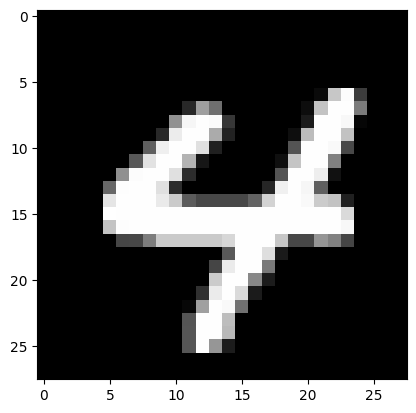

Predictions are [9]
Labels: 9


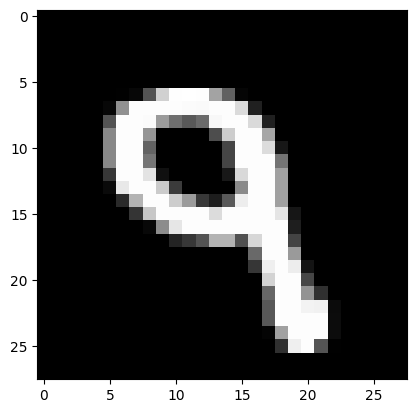

Predictions are [8]
Labels: 8


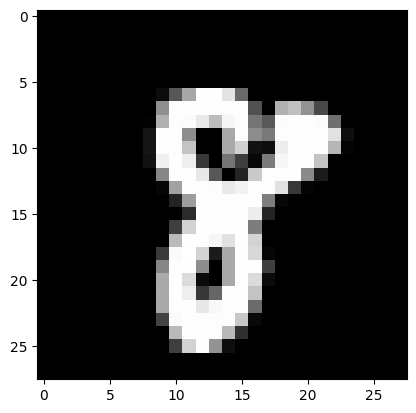

Predictions are [8]
Labels: 8


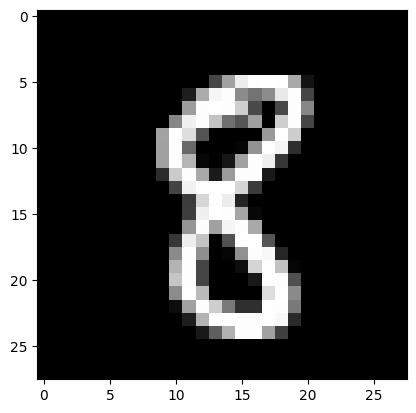

In [19]:
test_predictions(0, input, inputb, mid1, midb, output, outputb)
test_predictions(1, input, inputb, mid1, midb, output, outputb)
test_predictions(2, input, inputb, mid1, midb, output, outputb)
test_predictions(3, input, inputb, mid1, midb, output, outputb)